# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("album_sales.csv")
df.head()


,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


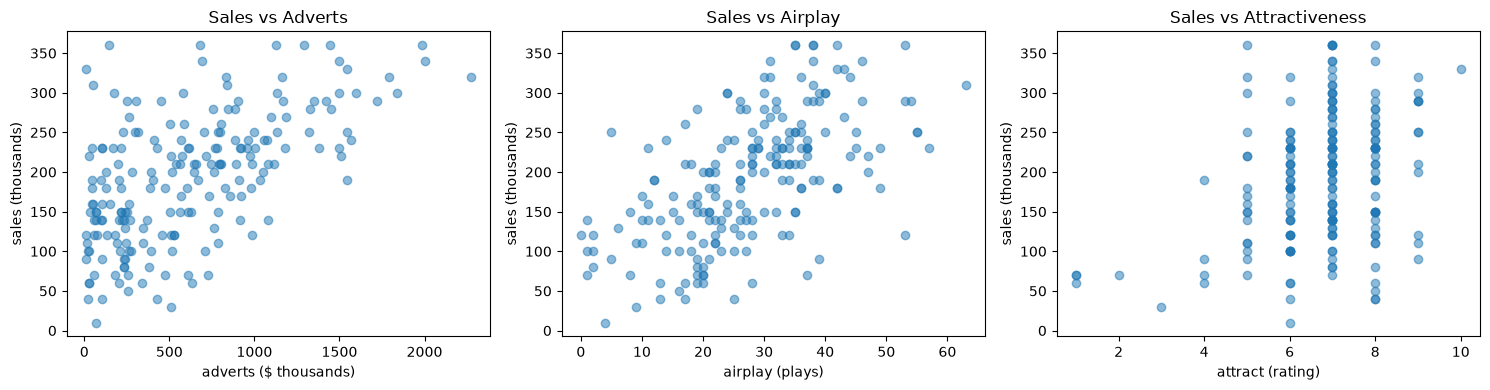

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['adverts'], df['sales'], alpha=0.5)
axes[0].set_xlabel('adverts ($ thousands)')
axes[0].set_ylabel('sales (thousands)')
axes[0].set_title('Sales vs Adverts')

axes[1].scatter(df['airplay'], df['sales'], alpha=0.5)
axes[1].set_xlabel('airplay (plays)')
axes[1].set_ylabel('sales (thousands)')
axes[1].set_title('Sales vs Airplay')

axes[2].scatter(df['attract'], df['sales'], alpha=0.5)
axes[2].set_xlabel('attract (rating)')
axes[2].set_ylabel('sales (thousands)')
axes[2].set_title('Sales vs Attractiveness')

plt.tight_layout()
plt.show()


In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

All three predictors show a positive relationship with sales, but they differ in strength.

- **sales vs. adverts**: a moderate positive, fairly linear relationship (r &asymp; 0.58) &mdash; albums with bigger ad budgets tend to sell more, though there is noticeable scatter around the trend.
- **sales vs. airplay**: also a moderate positive relationship, similar in strength to adverts (r &asymp; 0.60) &mdash; more radio plays are associated with higher sales.
- **sales vs. attract**: a much weaker positive relationship (r &asymp; 0.33) &mdash; the points are widely scattered at every attractiveness level, suggesting band attractiveness by itself is a poor predictor of sales.


### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [3]:
import statsmodels.api as sm

X = df['adverts']
y = df['sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        23:16:09   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-statistic is 99.59 with a Prob (F-statistic) of about 2.94e-19, which is far below the 0.05 significance threshold. This tells us the linear regression model as a whole is statistically significant &mdash; *adverts* explains a real, non-random amount of the variation in *sales*.

That said, the R-squared is only about 0.335, meaning advertising spend alone accounts for roughly a third of the variance in album sales. So the model is statistically **good** (significant) but not **complete** &mdash; most of the variation in sales is still left unexplained by adverts alone.


### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [4]:
intercept = model.params['const']
coefficient = model.params['adverts']

advertising_budget = 135  # $135,000, in the same thousands-of-dollars units as 'adverts'
predicted_sales = intercept + coefficient * advertising_budget

print(f"Intercept: {intercept:.4f}")
print(f"Coefficient (adverts): {coefficient:.4f}")
print(f"Predicted sales for $135,000 in advertising: {predicted_sales:.2f} thousand albums")


Intercept: 134.1399
Coefficient (adverts): 0.0961
Predicted sales for $135,000 in advertising: 147.12 thousand albums


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [5]:
X = df[['adverts', 'airplay', 'attract']]
y = df['sales']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        23:16:09   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

**Model 2 (the multiple regression model) is better.**

Model 1 (*sales* ~ *adverts*) has an R-squared of 0.335, while Model 2 (*sales* ~ *adverts* + *airplay* + *attract*) has an R-squared of 0.665 &mdash; nearly double, meaning it explains much more of the variance in sales. Both models are statistically significant (Model 1: F = 99.59, p &asymp; 2.94e-19; Model 2: F = 129.5, p &asymp; 2.88e-46), and in Model 2 all three predictors (*adverts*, *airplay*, *attract*) have individual p-values well below 0.05, so each contributes meaningfully. Since Model 2 has the higher R-squared and its p-value is also < 0.05, it is the better model.


### Submission to D2L Dropbox
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name

- Include the link to your GitHub repository (the URL of your repo page, for
   example `https://github.com/yourname/csci-4047-work`).
### How to add my code to GitHub?

1. Stage your file (this tells Git which changes to include):

      `git add Last_First_Assignment4.ipynb`

   To stage everything (you might not want to stage everything though) in the folder instead, use `git add .`

3. Commit your changes (this saves a snapshot with a message):

       git commit -m "Add Assignment 4"

   The text in quotes is your commit message. Make it describe what you
   did.

4. Push your commit up to GitHub:

       git push -u origin main

   The `-u origin main` part is only needed the first push. After that,
   `git push` alone is enough.

**What each command does, briefly**

- `git add` picks which files to include in the next save.
- `git commit` saves a snapshot of those files on your computer, with a
  message describing the change.
- `git push` uploads your saved commits to GitHub so they appear online.